In [1]:
# =========================
# CELL 1: IMPORTS
# =========================
import os
import re
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from src.data_pipeline import encode_labels

In [2]:
# =========================
# CELL 2: LOAD DATA AND LABELS WITH NOTEBOOK-SAFE PATHS
# =========================
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")

train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/RiceLeafs/train", regex=False
)
val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/RiceLeafs/validation", regex=False
)

train_df["full_path"] = train_df["filepath"].apply(lambda p: os.path.join("..", p))
val_df["full_path"] = val_df["filepath"].apply(lambda p: os.path.join("..", p))

train_df = train_df[train_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["full_path"].apply(os.path.exists)].reset_index(drop=True)

y_train, y_val, label_encoder, class_names = encode_labels(train_df, val_df)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Classes:", class_names)

Train shape: (2684, 4)
Validation shape: (671, 4)
Classes: ['BrownSpot' 'Healthy' 'Hispa' 'LeafBlast']


In [3]:
# =========================
# CELL 3: LOAD MODEL
# =========================
MODEL_PATH = "../experiments/results/best_efficientnetb0.keras"
model = load_model(MODEL_PATH)
print("Model loaded.")

Model loaded.


In [4]:
# =========================
# CELL 4: PREPROCESS IMAGE
# =========================
IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    img = tf.expand_dims(img, axis=0)
    return img

def show_image(image_path):
    img = plt.imread(image_path)
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [5]:
# =========================
# CELL 5: KNOWLEDGE BASE
# =========================
def normalize_label(label):
    return re.sub(r"[^a-z0-9]+", "", str(label).lower())

base_knowledge = {
    "brownspot": {
        "symptoms": "Small brown lesions develop on the leaves and may enlarge into circular or oval spots with darker borders.",
        "cause": "This disease is commonly associated with fungal infection and can worsen under poor nutrition or plant stress.",
        "action": "Inspect affected leaves, improve crop health, and apply appropriate disease management practices."
    },
    "leafblast": {
        "symptoms": "Diamond shaped lesions with gray or whitish centers and brown margins may appear on the leaves.",
        "cause": "This disease is caused by fungal infection and often spreads under humid conditions.",
        "action": "Monitor infected plants and consult recommended rice disease management practices."
    },
    "ricehispa": {
        "symptoms": "Leaves may show scraping damage, white streaks, or elongated feeding marks.",
        "cause": "This condition is associated with insect damage caused by rice hispa infestation.",
        "action": "Inspect for pest presence and apply recommended pest control measures when needed."
    },
    "healthy": {
        "symptoms": "Leaves appear normal, green, and free from visible lesions or severe discoloration.",
        "cause": "No clear disease symptoms are observed in the leaf image.",
        "action": "Continue regular crop monitoring and maintain good agricultural practices."
    }
}

knowledge_base = {}
for cls in class_names:
    key = normalize_label(cls)
    knowledge_base[cls] = base_knowledge.get(key, {
        "symptoms": f"{cls} affects the visible condition of the rice leaf.",
        "cause": f"{cls} may be associated with disease or stress conditions affecting rice plants.",
        "action": "Inspect the plant carefully and consult a local agriculture expert if needed."
    })

knowledge_base

{'BrownSpot': {'symptoms': 'Small brown lesions develop on the leaves and may enlarge into circular or oval spots with darker borders.',
  'cause': 'This disease is commonly associated with fungal infection and can worsen under poor nutrition or plant stress.',
  'action': 'Inspect affected leaves, improve crop health, and apply appropriate disease management practices.'},
 'Healthy': {'symptoms': 'Leaves appear normal, green, and free from visible lesions or severe discoloration.',
  'cause': 'No clear disease symptoms are observed in the leaf image.',
  'action': 'Continue regular crop monitoring and maintain good agricultural practices.'},
 'Hispa': {'symptoms': 'Hispa affects the visible condition of the rice leaf.',
  'cause': 'Hispa may be associated with disease or stress conditions affecting rice plants.',
  'action': 'Inspect the plant carefully and consult a local agriculture expert if needed.'},
 'LeafBlast': {'symptoms': 'Diamond shaped lesions with gray or whitish centers 

In [6]:
# =========================
# CELL 6: TF-IDF RETRIEVAL SETUP
# =========================
documents = []
doc_labels = []

for disease, info in knowledge_base.items():
    text = (
        f"{disease}. "
        f"Symptoms: {info['symptoms']} "
        f"Cause: {info['cause']} "
        f"Suggested action: {info['action']}"
    )
    documents.append(text)
    doc_labels.append(disease)

vectorizer = TfidfVectorizer(stop_words="english")
doc_vectors = vectorizer.fit_transform(documents)

print("Knowledge base ready.")

Knowledge base ready.


In [7]:
# =========================
# CELL 7: RETRIEVAL FUNCTION
# =========================
def retrieve_explanation(predicted_label):
    query = f"{predicted_label} rice leaf disease symptoms cause action"
    query_vector = vectorizer.transform([query])
    similarities = cosine_similarity(query_vector, doc_vectors)[0]

    best_idx = np.argmax(similarities)
    matched_label = doc_labels[best_idx]
    matched_info = knowledge_base[matched_label]

    explanation = (
        f"{matched_label} is the predicted class. "
        f"Common symptoms include {matched_info['symptoms'].lower()} "
        f"It is usually related to {matched_info['cause'].lower()} "
        f"A possible next step is to {matched_info['action'].lower()}"
    )

    return matched_label, explanation, similarities[best_idx]

In [8]:
# =========================
# CELL 8: PREDICTION WITH NLP
# =========================
def predict_with_explanation(image_path):
    img = preprocess_image(image_path)
    probs = model.predict(img, verbose=0)[0]

    pred_idx = np.argmax(probs)
    predicted_label = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    matched_label, explanation, retrieval_score = retrieve_explanation(predicted_label)

    return {
        "predicted_label": predicted_label,
        "confidence": confidence,
        "matched_label": matched_label,
        "retrieval_score": float(retrieval_score),
        "explanation": explanation,
        "all_probabilities": probs
    }

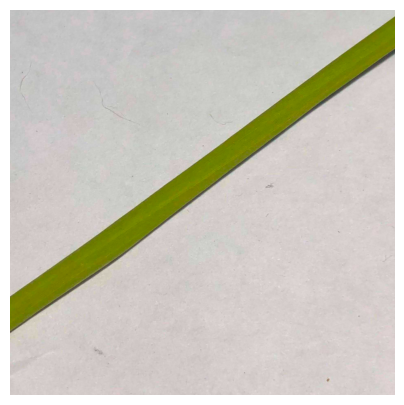

=== CNN + NLP OUTPUT ===
True Label        : Healthy
Predicted Disease : Hispa
Confidence        : 0.4293
Retrieved Label   : Hispa
Retrieval Score   : 0.6343
Explanation       : Hispa is the predicted class. Common symptoms include hispa affects the visible condition of the rice leaf. It is usually related to hispa may be associated with disease or stress conditions affecting rice plants. A possible next step is to inspect the plant carefully and consult a local agriculture expert if needed.


In [9]:
# =========================
# CELL 9: TEST SAMPLE
# =========================
sample_row = val_df.sample(1, random_state=42).iloc[0]
sample_path = sample_row["full_path"]
true_label = sample_row["label"]

show_image(sample_path)
result = predict_with_explanation(sample_path)

print("=== CNN + NLP OUTPUT ===")
print("True Label        :", true_label)
print("Predicted Disease :", result["predicted_label"])
print("Confidence        :", f"{result['confidence']:.4f}")
print("Retrieved Label   :", result["matched_label"])
print("Retrieval Score   :", f"{result['retrieval_score']:.4f}")
print("Explanation       :", result["explanation"])

In [10]:
# =========================
# CELL 10: CLASS PROBABILITIES
# =========================
pd.DataFrame({
    "Class": class_names,
    "Probability": result["all_probabilities"]
}).sort_values(by="Probability", ascending=False).reset_index(drop=True)

,Class,Probability
0,Hispa,0.429267
1,BrownSpot,0.258964
2,Healthy,0.169831
3,LeafBlast,0.141938


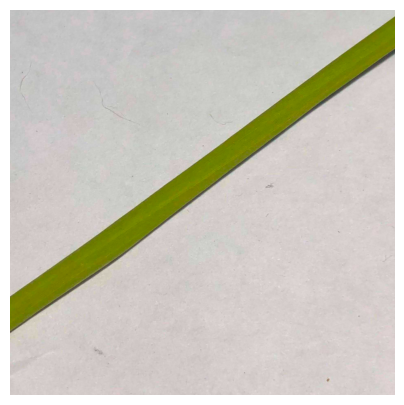

=== CUSTOM CNN + NLP OUTPUT ===
Predicted Disease : Hispa
Confidence        : 0.4293
Retrieved Label   : Hispa
Retrieval Score   : 0.6343
Explanation       : Hispa is the predicted class. Common symptoms include hispa affects the visible condition of the rice leaf. It is usually related to hispa may be associated with disease or stress conditions affecting rice plants. A possible next step is to inspect the plant carefully and consult a local agriculture expert if needed.


In [12]:
# =========================
# CELL 11: OPTIONAL CUSTOM IMAGE TEST
# =========================
# Example:
custom_image_path = "../data/raw/RiceLeafs/validation/BrownSpot/example.jpg"

custom_image_path = sample_path  # replace with your own image path if needed

show_image(custom_image_path)
custom_result = predict_with_explanation(custom_image_path)

print("=== CUSTOM CNN + NLP OUTPUT ===")
print("Predicted Disease :", custom_result["predicted_label"])
print("Confidence        :", f"{custom_result['confidence']:.4f}")
print("Retrieved Label   :", custom_result["matched_label"])
print("Retrieval Score   :", f"{custom_result['retrieval_score']:.4f}")
print("Explanation       :", custom_result["explanation"])